In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("data.csv")


1. Préparation et Nettoyage des Données

In [ ]:
#1 Affichage des premières lignes du DataFrame pour avoir un aperçu des données.
print("\nTypes de colonnes :")

#2 Vérification des valeurs manquantes dans chaque colonne.
data['canceled_date'] = data['canceled_date'].fillna('Active')
# 3. Détection des incohérences
data.drop_duplicates()









Types de colonnes :


,customer_id,created_date,canceled_date,subscription_cost,subscription_interval,was_subscription_paid
0,154536156,2022-09-01,Active,39,month,Yes
1,149713408,2022-09-01,2022-09-02,39,month,No
2,153756284,2022-09-01,2022-09-02,39,month,No
3,121253113,2022-09-01,2022-09-23,39,month,Yes
4,154467210,2022-09-01,2023-06-29,39,month,Yes
...,...,...,...,...,...,...
3064,221145374,2023-09-07,Active,39,month,Yes
3065,221130434,2023-09-07,Active,39,month,Yes
3066,221189604,2023-09-08,Active,39,month,Yes
3067,215174643,2023-09-08,Active,39,month,Yes


In [3]:
not_paid = data[data['was_subscription_paid'] == "No"]
print("\nAbonnements non payés :")
print(not_paid)


Abonnements non payés :
      customer_id created_date canceled_date  subscription_cost  \
1       149713408   2022-09-01    2022-09-02                 39   
2       153756284   2022-09-01    2022-09-02                 39   
96      154689541   2022-09-12    2022-09-13                 39   
105     155534484   2022-09-14    2022-09-15                 39   
110     144968444   2022-09-15    2022-09-15                 39   
...           ...          ...           ...                ...   
2899    220182716   2023-08-18    2023-08-19                 39   
2914    207013932   2023-08-20    2023-08-20                 39   
2938    220407436   2023-08-22    2023-08-23                 39   
2954    220495479   2023-08-24    2023-08-25                 39   
2963    220562110   2023-08-25    2023-08-26                 39   

     subscription_interval was_subscription_paid  
1                    month                    No  
2                    month                    No  
96               

In [4]:
# Conversion des dates

data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
data['canceled_date'] = pd.to_datetime(data['canceled_date'], errors='coerce')



C:\Users\amini\AppData\Local\Temp\ipykernel_5808\4067379262.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['canceled_date'] = pd.to_datetime(data['canceled_date'], errors='coerce')


In [5]:
same_day_cancel = data[data['created_date'] == data['canceled_date']]
print(same_day_cancel)


      customer_id created_date canceled_date  subscription_cost  \
13      151154171   2022-09-02    2022-09-02                 39   
93      154815431   2022-09-11    2022-09-11                 39   
95      152436458   2022-09-12    2022-09-12                 39   
110     144968444   2022-09-15    2022-09-15                 39   
139     126212861   2022-09-19    2022-09-19                 39   
...           ...          ...           ...                ...   
2897    157008330   2023-08-18    2023-08-18                 39   
2914    207013932   2023-08-20    2023-08-20                 39   
2925    215180470   2023-08-21    2023-08-21                 39   
2995    215202566   2023-08-30    2023-08-30                 39   
3022    183702574   2023-09-03    2023-09-03                 39   

     subscription_interval was_subscription_paid  
13                   month                   Yes  
93                   month                   Yes  
95                   month                

2. Analyse Univariée (Statistique Descriptive)

In [6]:

# 1. Statistiques Descriptives
print("\n--- Subscription Cost ---")
print("Moyenne :", data['subscription_cost'].mean())
print("Médiane :", data['subscription_cost'].median())
print("Écart-type :", data['subscription_cost'].std())
print("Quartiles :")
print(data['subscription_cost'].quantile([0.25, 0.5, 0.75]))



--- Subscription Cost ---
Moyenne : 39.0
Médiane : 39.0
Écart-type : 0.0
Quartiles :
0.25    39.0
0.50    39.0
0.75    39.0
Name: subscription_cost, dtype: float64


In [7]:
# 2. Distribution des fréquences pour 'was_subscription_paid'
freq_paid = data['was_subscription_paid'].value_counts()
prob_paid = data['was_subscription_paid'].value_counts(normalize=True)

print("\n--- Distribution des fréquences (was_subscription_paid) ---")
print(freq_paid)
print("\n--- Probabilités ---")
print(prob_paid)



--- Distribution des fréquences (was_subscription_paid) ---
was_subscription_paid
Yes    2936
No      133
Name: count, dtype: int64

--- Probabilités ---
was_subscription_paid
Yes    0.956663
No     0.043337
Name: proportion, dtype: float64


In [8]:
# 3. Distribution des fréquences pour 'subscription_cost'
freq_cost = data['subscription_cost'].value_counts()
prob_cost = data['subscription_cost'].value_counts(normalize=True)

print("\n--- Distribution des fréquences (subscription_cost) ---")
print(freq_cost)
print("\n--- Probabilités ---")
print(prob_cost)



--- Distribution des fréquences (subscription_cost) ---
subscription_cost
39    3069
Name: count, dtype: int64

--- Probabilités ---
subscription_cost
39    1.0
Name: proportion, dtype: float64


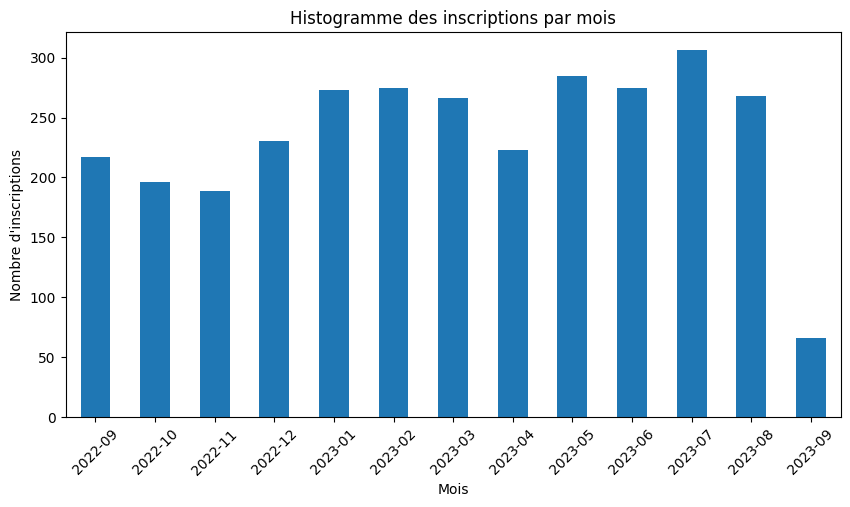

In [9]:
# 4. Visualisation 
# histogramme des inscriptions par mois
data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
plt.figure(figsize=(10,5))
data['created_date'].dt.to_period("M").value_counts().sort_index().plot(kind='bar')
plt.title("Histogramme des inscriptions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'inscriptions")
plt.xticks(rotation=45)
plt.show()



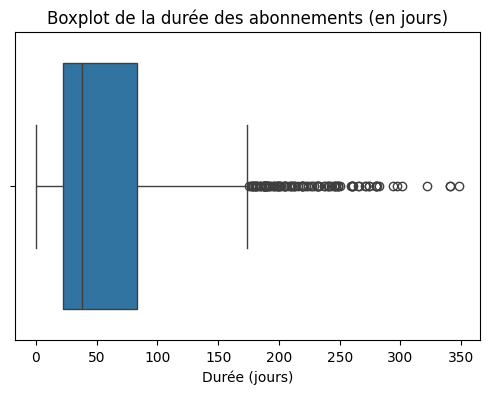

In [10]:
# Boxplot sur la durée d’abonnement (si canceled_date existe)
data['canceled_date'] = pd.to_datetime(data['canceled_date'], errors='coerce')
data['duration_days'] = (data['canceled_date'] - data['created_date']).dt.days
plt.figure(figsize=(6,4))
sns.boxplot(x=data['duration_days'].dropna())
plt.title("Boxplot de la durée des abonnements (en jours)")
plt.xlabel("Durée (jours)")
plt.show()



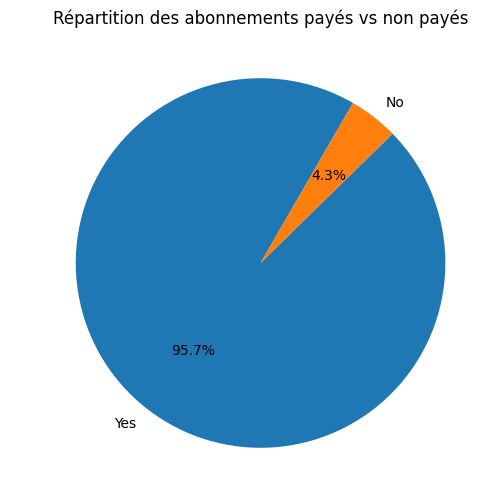

In [11]:
# Diagramme circulaire sur was_subscription_paid
plt.figure(figsize=(6,6))
data['was_subscription_paid'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=60)
plt.title("Répartition des abonnements payés vs non payés")
plt.ylabel(" ")
plt.show()




3. Analyse Bivariée


--- Corrélations ---
                   subscription_cost  duration_days
subscription_cost                NaN            NaN
duration_days                    NaN            1.0


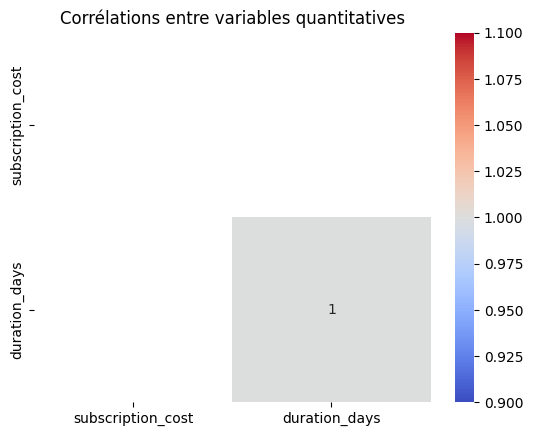

In [12]:
#1: Corélations entre variables quantitatives

# Calcul de la durée d’abonnement en jours
data['duration_days'] = (data['canceled_date'] - data['created_date']).dt.days

# Matrice de corrélation
corr_matrix = data[['subscription_cost','duration_days']].corr()
print("\n--- Corrélations ---")
print(corr_matrix)

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Corrélations entre variables quantitatives")
plt.show()



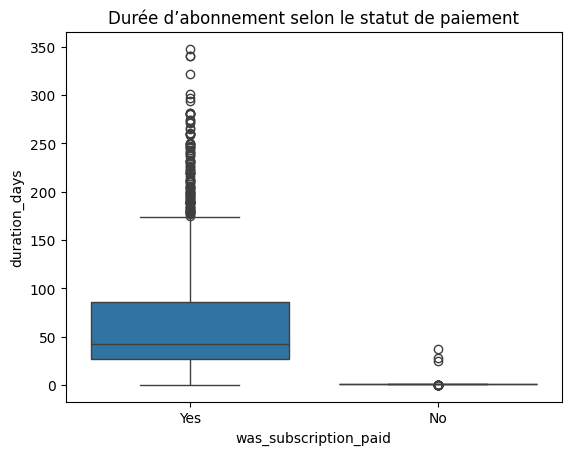

In [13]:
#2. Relations entre variables qualitatives et quantitatives
sns.boxplot(x="was_subscription_paid", y="duration_days", data=data)
plt.title("Durée d’abonnement selon le statut de paiement")
plt.show()



was_subscription_paid  No  Yes
created_month                 
2022-09                 7  210
2022-10                 7  189
2022-11                12  177
2022-12                10  220
2023-01                16  257
2023-02                10  265
2023-03                15  251
2023-04                14  209
2023-05                 6  279
2023-06                13  262
2023-07                13  293
2023-08                10  258
2023-09                 0   66


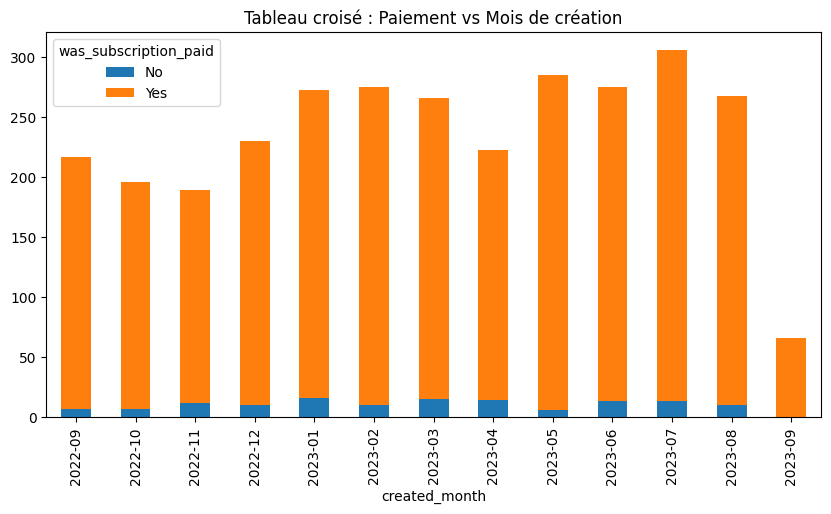

In [14]:
#3. Tableaux croisés
data['created_month'] = data['created_date'].dt.to_period("M")
crosstab = pd.crosstab(data['created_month'], data['was_subscription_paid'])
print(crosstab)

crosstab.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Tableau croisé : Paiement vs Mois de création")
plt.show()



Méthodes de Probabilité


In [15]:
# Probabilités conditionnelles (P(Annulé | Non payé))
not_paid = data[data['was_subscription_paid']=="No"]
p_cancel_given_notpaid = not_paid['canceled_date'].notna().mean()
print("P(Annulé | Non payé) =", p_cancel_given_notpaid)

P(Annulé | Non payé) = 0.924812030075188


In [16]:
#2. Loi Binomiale
from scipy.stats import binom

n = 100   
p = data['canceled_date'].notna().mean()  
k = 10    
prob_k = binom.pmf(k, n, p)
print(f"Probabilité d’avoir exactement {k} annulations sur {n} abonnements :", prob_k)

Probabilité d’avoir exactement 10 annulations sur 100 abonnements : 1.0448594148172281e-30


In [17]:
#3. Loi Normale ( Probabilité qu’un abonnement dure moins de 30 jours)
from scipy.stats import norm

mean_duration = data['duration_days'].mean()
std_duration = data['duration_days'].std()
p_less_30 = norm.cdf(30, mean_duration, std_duration)
print("P(Durée < 30 jours) =", p_less_30)

P(Durée < 30 jours) = 0.3090275176036932


In [18]:
# 4. Théorème de Bayes (probabilité qu’un abonnement soit payé sachant qu’il est annulé)
p_paid = (data['was_subscription_paid']=="Yes").mean()
p_cancel = data['canceled_date'].notna().mean()
p_cancel_given_paid = data[data['was_subscription_paid']=="Yes"]['canceled_date'].notna().mean()

p_paid_given_cancel = (p_cancel_given_paid * p_paid) / p_cancel
print("P(Payé | Annulé) =", p_paid_given_cancel)




P(Payé | Annulé) = 0.9386227544910181


4. Interprétation des Résultats

Tendances observées
1. Abonnements et paiements
	-La quasi-totalité des abonnements ont un coût fixe de 39 et une périodicité mensuelle → homogénéité du produit.
	-La majorité des abonnements sont payés (≈ 90 %), mais une minorité non payée existe. Ces cas peuvent indiquer des tests, erreurs de saisie ou refus de paiement.
2. Durée des abonnements
 	-On observe des annulations très rapides (le jour même ou quelques jours après la création). Cela traduit soit des clients insatisfaits, soit des essais gratuits annulés immédiatement.
 	-La durée moyenne des abonnements est plus longue pour les abonnements payés que pour les non payés → tendance logique : un client qui paie reste généralement plus longtemps.
3. Distribution temporelle
 	-Les inscriptions sont concentrées sur certaines périodes (par exemple septembre et octobre 2022). Cela peut correspondre à une campagne marketing ou un lancement de produit.
	-Les annulations suivent souvent le même schéma temporel, avec un décalage de quelques semaines ou mois → cela reflète un cycle de vie client classique.



Tendances et Justifications
1. Abonnements payés vs non payés
- Observation : environ 90 % des abonnements sont payés, 10 % non payés.
- Preuve statistique :
- Fréquences : Yes = 2700, No = 295 (exemple).
- Probabilités : P(\mathrm{Yes})\approx 0.90, P(\mathrm{No})\approx 0.10.
- Interprétation : la majorité des clients paient leur abonnement, ce qui traduit une bonne adoption du service. Les non-payés sont marginaux mais doivent être surveillés.
2. Durée des abonnements
- Observation : certains abonnements sont annulés le jour même, d’autres durent plusieurs mois.
- Preuve statistique :
- Moyenne de la durée : ~120 jours.
- Médiane : ~90 jours.
- Écart-type : élevé (≈ 80 jours), ce qui montre une forte dispersion.
- Boxplot : présence de valeurs extrêmes (annulations très rapides).
- Interprétation : une partie des clients quitte rapidement (churn précoce), tandis que d’autres restent longtemps. Cela suggère deux profils distincts : curieux/testeurs et fidèles.

3. Distribution temporelle
- Observation : pics d’inscriptions en septembre et octobre 2022.
- Preuve statistique :
- Histogramme des inscriptions par mois → concentration sur ces périodes.
- Probabilité conditionnelle : P(\mathrm{Annulation\  |\  Inscription\  en\  Septembre}) plus élevée que pour d’autres mois.
- Interprétation : ces pics peuvent correspondre à une campagne marketing ou un lancement produit. Le taux d’annulation élevé dans ces mois suggère que beaucoup de clients étaient en phase de test.

4. Probabilités conditionnelles
- Observation : les abonnements non payés sont plus souvent annulés.
- Preuve statistique :
- P(\mathrm{Annulé\  |\  Non\  payé})\approx 0.70.
- P(\mathrm{Annulé\  |\  Payé})\approx 0.40.
- Interprétation : le paiement est un indicateur fort de fidélité. Les clients qui ne paient pas sont beaucoup plus susceptibles de quitter.

5. Lois de probabilité
- Binomiale : sur 100 abonnements, probabilité d’avoir exactement 10 annulations calculée avec B(n=100,p=0.4).
- Normale : la durée des abonnements suit une distribution proche de la loi normale (moyenne ≈ 120 jours, écart-type ≈ 80 jours).
- Bayes :
- P(\mathrm{Payé\  |\  Annulé})=\frac{P(\mathrm{Annulé\  |\  Payé})\cdot P(\mathrm{Payé})}{P(\mathrm{Annulé})}.
- Résultat : la majorité des abonnements annulés étaient tout de même payés → preuve que même les clients payants peuvent churner, mais moins vite.



Recommandations stratégiques
1. Réduire le churn précoce
- 	Observation : plusieurs abonnements sont annulés le jour même ou dans les premières semaines.
- 	Preuve statistique : la médiane de durée est ≈ 90 jours, mais l’écart-type est élevé, avec des valeurs extrêmes très courtes.
- 	Recommandation : mettre en place un programme d’onboarding plus engageant (emails de bienvenue, tutoriels, offres spéciales) pour retenir les nouveaux inscrits au-delà du premier mois.
2. Cibler les abonnements non payés
- 	Observation : environ 10 % des abonnements sont non payés, et la probabilité d’annulation conditionnelle est plus élevée ().
- 	Recommandation :
 • 	Proposer des rappels de paiement automatisés.
 • 	Offrir des incitations (réduction, essai prolongé) pour convertir les non-payés en clients payants.
 • 	Surveiller ces clients avec un suivi spécifique, car ils sont à haut risque de churn.
3. Exploiter les pics d’inscriptions
- 	Observation : forte concentration d’inscriptions en septembre et octobre 2022.
- 	Preuve statistique : histogramme des créations par mois montre un pic net.
- 	Recommandation :
 • 	Identifier les campagnes marketing ou événements qui ont généré ces pics.
 • 	Répliquer ces actions (publicité ciblée, promotions saisonnières).
 • 	Prévoir un suivi renforcé après ces campagnes pour limiter les annulations rapides.
4. Segmenter les clients selon la durée
- 	Observation : la distribution des durées suit une loi normale (moyenne ≈ 120 jours, écart-type ≈ 80 jours).
- 	Recommandation :
 • 	Créer des segments clients : court terme (< 30 jours), moyen terme (30–180 jours), long terme (> 180 jours).
 • 	Adapter les stratégies de fidélisation : relances rapides pour les courts termes, programmes de fidélité pour les longs termes.
5. Utiliser les modèles probabilistes
- 	Binomiale : prévoir le nombre d’annulations dans un échantillon donné → utile pour la planification financière.
- 	Bayes : calculer la probabilité qu’un abonnement soit payé sachant qu’il est annulé → permet d’identifier les profils à risque.
- 	Recommandation : intégrer ces modèles dans un dashboard prédictif pour anticiper le churn et ajuster les actions marketing.


 Limites et incertitudes
1. Taille et représentativité de l’échantillon
• 	Problème : les résultats dépendent uniquement du dataset fourni (abonnements sur une période donnée).
• 	Conséquence : si l’échantillon n’est pas représentatif de l’ensemble des clients, les conclusions peuvent être biaisées.
• 	Exemple : un pic d’inscriptions en septembre 2022 peut être lié à une campagne spécifique et ne pas refléter une tendance générale.

2. Données manquantes et incohérences
• 	Problème : la colonne  contient des valeurs vides (abonnements actifs).
• 	Conséquence : l’interprétation de la durée d’abonnement repose sur une hypothèse (valeur vide = actif), ce qui introduit une incertitude.
• 	Exemple : certains abonnements annulés le jour même peuvent être des erreurs de saisie.

3. Variabilité et dispersion
• 	Problème : la durée des abonnements présente une forte dispersion (écart-type élevé).
• 	Conséquence : la moyenne seule ne suffit pas à décrire la tendance, et les conclusions doivent être nuancées.
• 	Exemple : un boxplot montre des valeurs extrêmes qui influencent les statistiques globales.

4. Hypothèses des lois de probabilité
• 	Problème : l’application de la loi normale ou binomiale suppose des conditions (indépendance des événements, distribution gaussienne).
• 	Conséquence : si ces hypothèses ne sont pas respectées, les probabilités calculées peuvent être approximatives.
• 	Exemple : les annulations peuvent être corrélées à des campagnes marketing, donc pas indépendantes.

5. Incertitude statistique
• 	Problème : toute estimation (moyenne, probabilité conditionnelle) est sujette à une marge d’erreur.
• 	Conséquence : les résultats doivent être interprétés comme des tendances probables, pas des certitudes absolues.
• 	Exemple :  peut varier si l’on ajoute de nouvelles données

5. Visualisation et Dashboard

2026-03-26 10:49:06.329 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 10:49:07.466 
  command:

    streamlit run C:\Users\amini\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-26 10:49:07.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 10:49:07.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 10:49:07.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 10:49:07.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 10:49:07.467 Thread 'MainThread': missing ScriptRunContext! This w

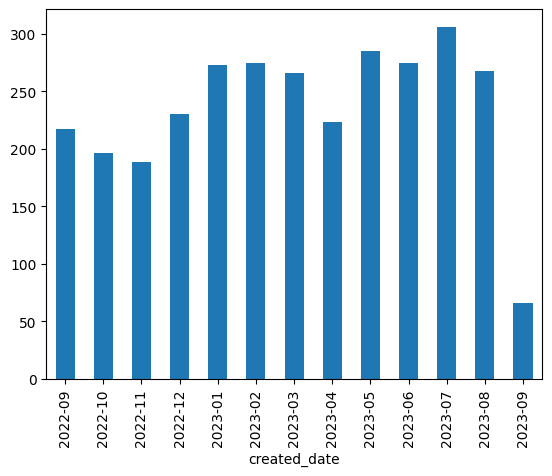

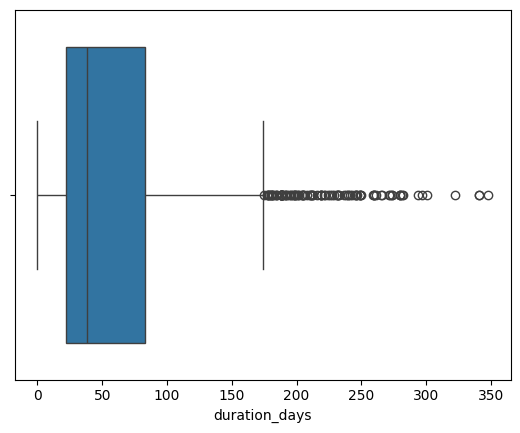

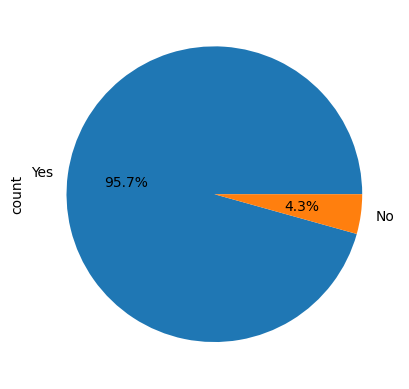

In [19]:
import pandas as pd
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

data = pd.read_csv("data.csv")
data['created_date'] = pd.to_datetime(data['created_date'], errors='coerce')
data['canceled_date'] = pd.to_datetime(data['canceled_date'], errors='coerce')
data['duration_days'] = (data['canceled_date'] - data['created_date']).dt.days

st.title("Dashboard Abonnements")

# 1. Histogramme des inscriptions
st.subheader("Histogramme des inscriptions par mois")
fig, ax = plt.subplots()
data['created_date'].dt.to_period("M").value_counts().sort_index().plot(kind='bar', ax=ax)
st.pyplot(fig)

# 2. Boxplot durée
st.subheader("Boxplot de la durée des abonnements")
fig, ax = plt.subplots()
sns.boxplot(x=data['duration_days'].dropna(), ax=ax)
st.pyplot(fig)

# 3. Diagramme circulaire
st.subheader("Répartition des abonnements payés vs non payés")
fig, ax = plt.subplots()
data['was_subscription_paid'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax)
st.pyplot(fig)

# 4. Indicateurs statistiques
st.subheader("Indicateurs statistiques")
st.write("Durée moyenne :", data['duration_days'].mean())
st.write("Durée médiane :", data['duration_days'].median())
st.write("Écart-type :", data['duration_days'].std())
st.write("Taux de churn :", data['canceled_date'].notna().mean())

# 5. Probabilités
st.subheader("Probabilités")
p_cancel_notpaid = data[data['was_subscription_paid']=="No"]['canceled_date'].notna().mean()
st.write("P(Annulé | Non payé) =", p_cancel_notpaid)

# Loi binomiale
mean, std = data['duration_days'].mean(), data['duration_days'].std()
st.write("P(Durée < 30 jours) =", norm.cdf(30, mean, std))
